## Working with the `PaintBall` class

The `PaintBall` class is intended to be a user-friendly way to generate and preview 
the "paintball" plots that sometimes appear in reports authored by the Data and Democracy
Lab. 

> NOTE: Usage of the `preview` function of the `PaintBall` class does require a latex compiler be 
> installed on the machine that you are working from.

### Basic construction

The `PaintBall` class comes with a basic previewer and a minimal interface so that producing the
plot is as painless as possible. By default, the plot will display the region 
$[0,1] \times [0,1]$ and will show the proporitionality line (dashed grey) and the efficiency-gap
line (solid grey).

/mnt/efs/h/Dropbox/MADLAB/Git_Repos/peter/gerrytools-dev/gerrytools/__init__.py:9: UserWarning: pygeos support was removed in 1.0. geopandas.use_pygeos is a no-op and will be removed in geopandas 1.1.
  geopandas.options.use_pygeos = False


\begin{tikzpicture}
\begin{scope}[xscale=10, yscale=10]

\clip [draw] (0.0, 0) rectangle (1.0, 1);

\draw [line width=5.0pt, color=gray!50] (0.5, 0) -- (0.5, 1);
\draw [line width=5.0pt, color=gray!50] (0, 0.5) -- (1, 0.5);

\draw [color=gray, line width=1.0pt, solid] (0.25, 0.0) -- (0.75, 1.0);
\draw [color=gray, line width=1.0pt, dashed] (0.0, 0.0) -- (1.0, 1.0);

\foreach \votes/\seats in {
    0.4925/0.2778,
    0.5233/0.5556,
    0.496/0.5,
    0.5259/0.5,
    0.4839/0.3889,
    0.534/0.5556,
    0.5867/0.6667,
    0.4962/0.4444,
    0.5667/0.6111,
    0.5139/0.5556,
    0.506/0.5,
    0.5493/0.5
} {
    \node[transform shape=false, circle , fill=cadmiumgreen, fill opacity=0.8, inner sep=0pt, minimum size=8pt, draw=cadmiumgreen, line width=0.5, draw opacity=1.0] 
    at (1-\votes, 1-\seats) {{}};
}

\end{scope}
\end{tikzpicture}



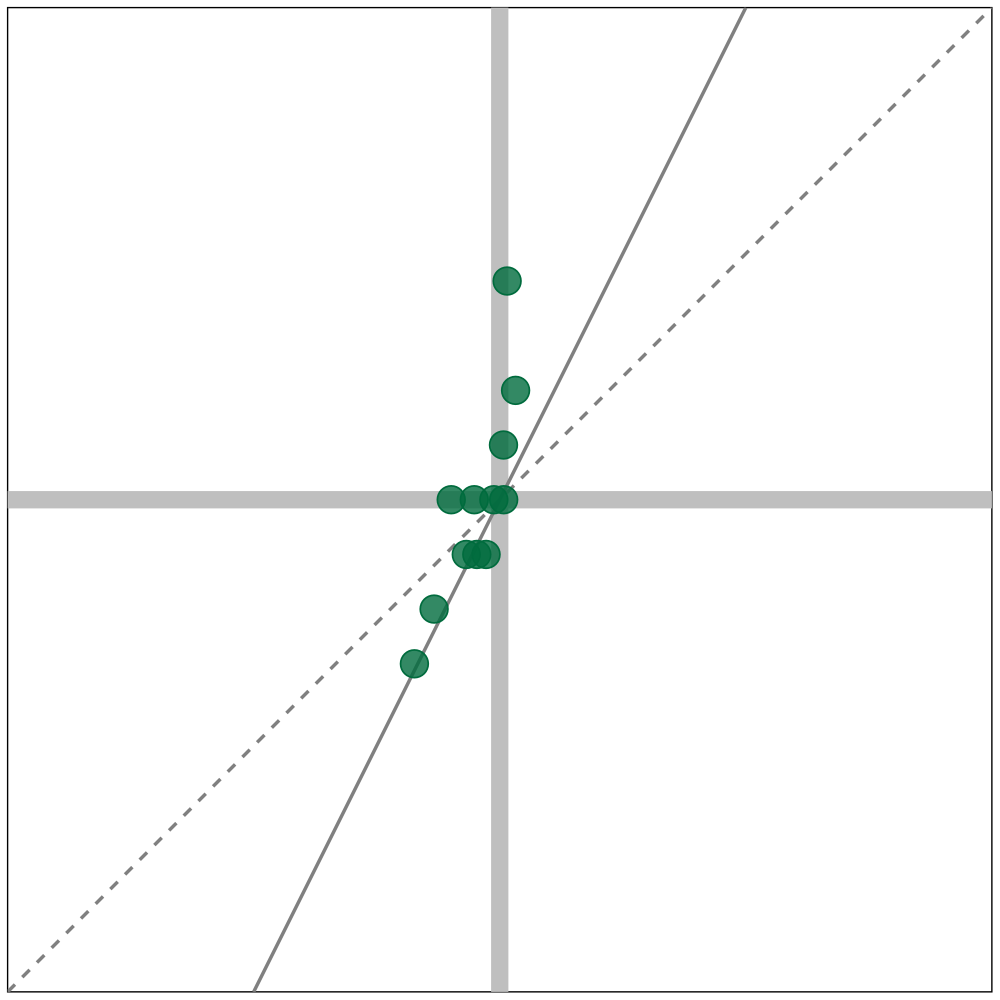

In [1]:
from gerrytools.latex import PaintBall
plot = PaintBall(
    voteshare_data=[0.4925, 0.5233, 0.4960, 0.5259, 0.4839, 0.5340, 0.5867, 0.4962, 0.5667, 0.5139, 0.5060, 0.5493],
    seats_data=[5,10,9,9,7,10,12,8,11,10,9,9],
    maximum_seats=18
)

plot.print()
plot.preview()

In the creation of the plot object, it is also possible to just pass the seatshare data to the
constructor rather than passing the seats and the maximum number of allowable seats.

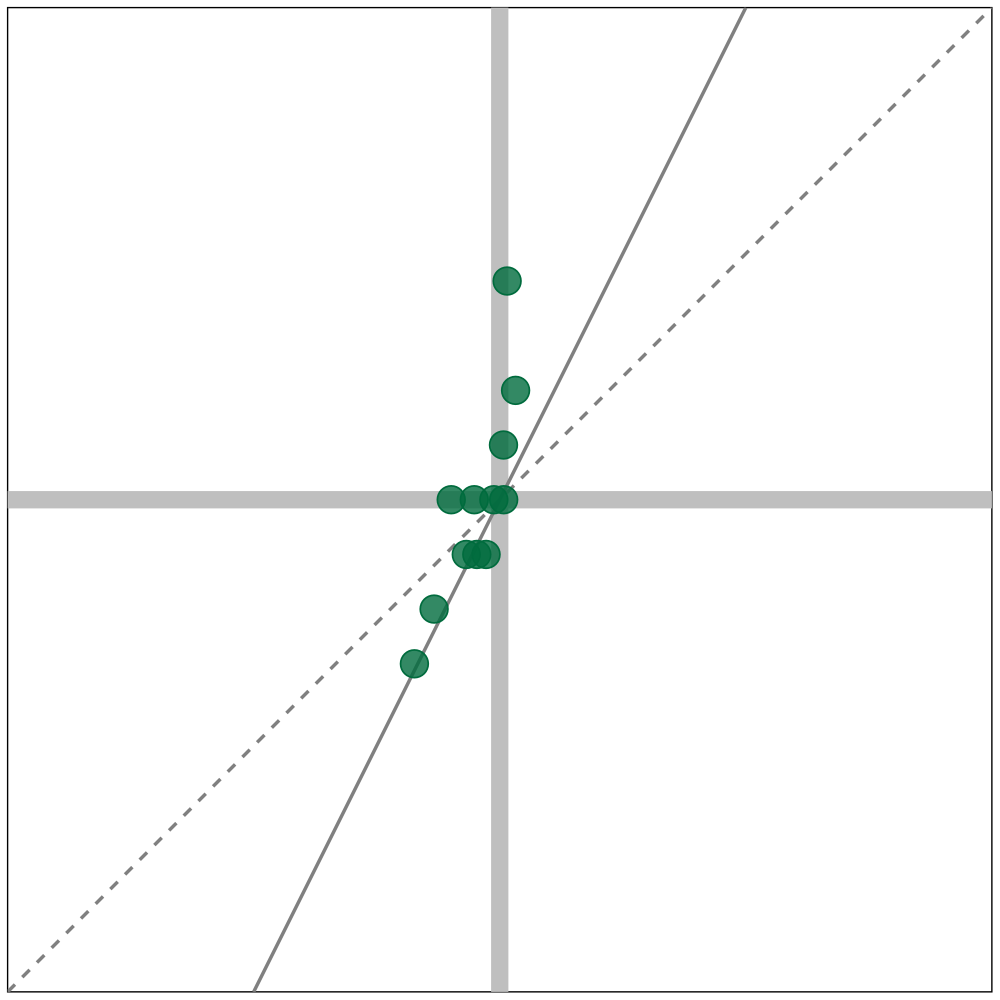

In [2]:
import numpy as np

plot = PaintBall(
    voteshare_data=[0.4925, 0.5233, 0.4960, 0.5259, 0.4839, 0.5340, 0.5867, 0.4962, 0.5667, 0.5139, 0.5060, 0.5493],
    seats_data=np.array([5,10,9,9,7,10,12,8,11,10,9,9])/18,
)
plot.preview()


Frequently, when working with paintball plots, it is desirable to adjust the $x$ and $y$ limits.
There are functions that accomplish this, and, by default, they also rescale the image so that
the aspect ratio is still 1-1.

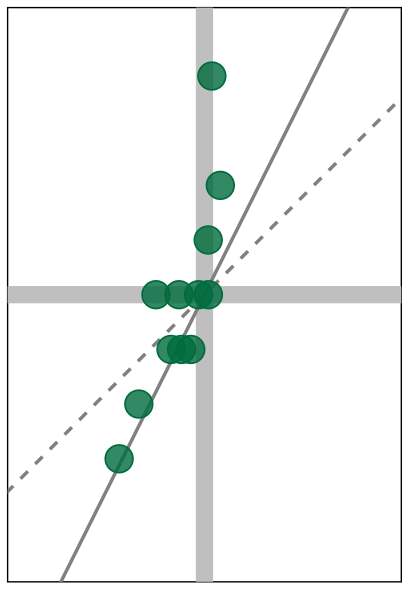

In [3]:
plot = PaintBall(
    voteshare_data=[0.4925, 0.5233, 0.4960, 0.5259, 0.4839, 0.5340, 0.5867, 0.4962, 0.5667, 0.5139, 0.5060, 0.5493],
    seats_data=[5,10,9,9,7,10,12,8,11,10,9,9],
    maximum_seats=18
)

plot.set_xlim(0.3, 0.7)
plot.set_ylim(3.75/18, 14.25/18)
plot.preview()

If rescaling is undesirable, then there is a parameter that allows users to avoid this:

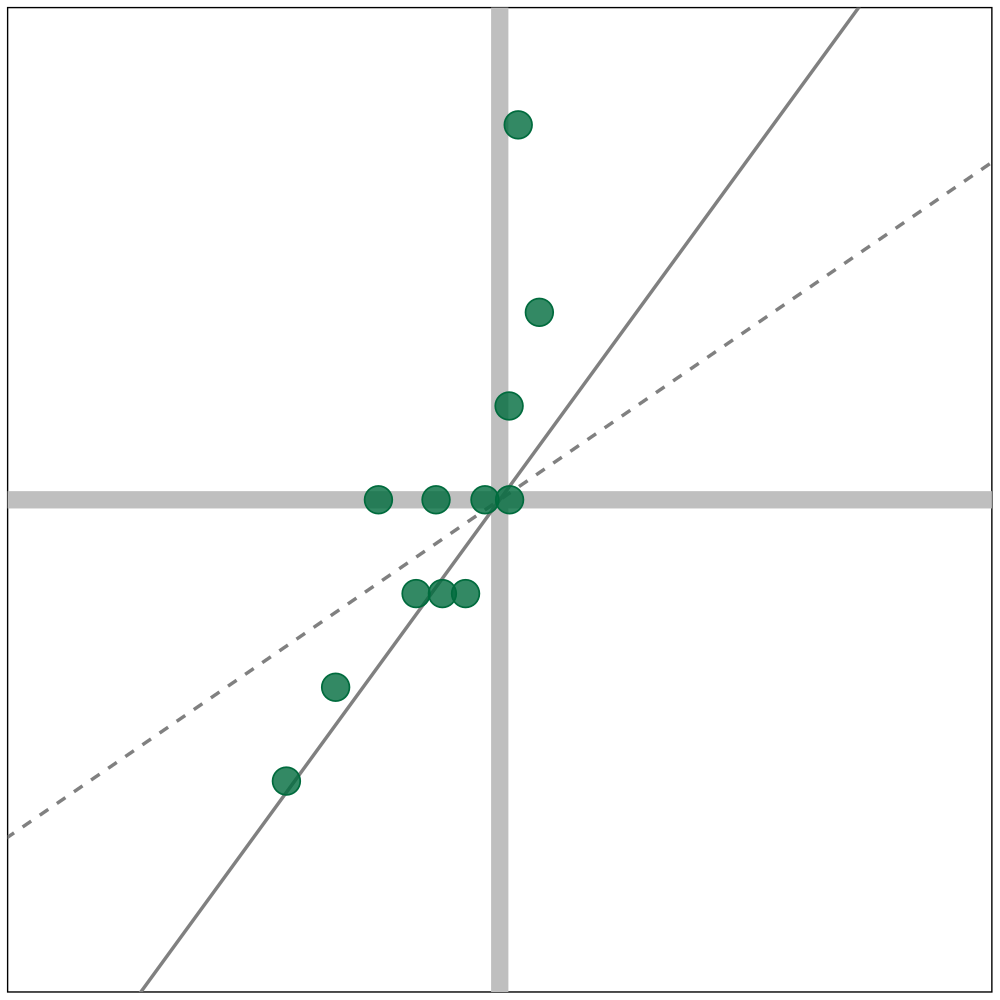

In [4]:
plot = PaintBall(
    voteshare_data=[0.4925, 0.5233, 0.4960, 0.5259, 0.4839, 0.5340, 0.5867, 0.4962, 0.5667, 0.5139, 0.5060, 0.5493],
    seats_data=[5,10,9,9,7,10,12,8,11,10,9,9],
    maximum_seats=18
)

plot.set_xlim(0.3, 0.7, rescale = True)
plot.set_ylim(3.75/18, 14.25/18, rescale = True)
plot.preview()

In addition to the main paintball plot, there is also an option to generate and preview the 
horizontal hull of the paintball plot.

\begin{tikzpicture}
\begin{scope}[xscale=10, yscale=10]

\clip [draw] (0.0, 0) rectangle (1.0, 1);

\draw [line width=5.0pt, color=gray!50] (0.5, 0) -- (0.5, 1);
\draw [line width=5.0pt, color=gray!50] (0, 0.5) -- (1, 0.5);

\draw [color=gray, line width=1.0pt, solid] (0.25, 0.0) -- (0.75, 1.0);
\draw [color=gray, line width=1.0pt, dashed] (0.0, 0.0) -- (1.0, 1.0);

\draw [fill=cadmiumgreen, fill opacity=0.8, line width=2.0, color=cadmiumgreen, draw opacity=1.0] 
  (0.4133,0.3333)--
  (0.4333,0.3889)--
  (0.466,0.4444)--
  (0.4507,0.5)--
  (0.5038,0.5556)--
  (0.5161,0.6111)--
  (0.5075,0.7222)--
  (0.5075,0.7222)--
  (0.5161,0.6111)--
  (0.5038,0.5556)--
  (0.504,0.5)--
  (0.4861,0.4444)--
  (0.4333,0.3889)--
  (0.4133,0.3333);

\end{scope}
\end{tikzpicture}



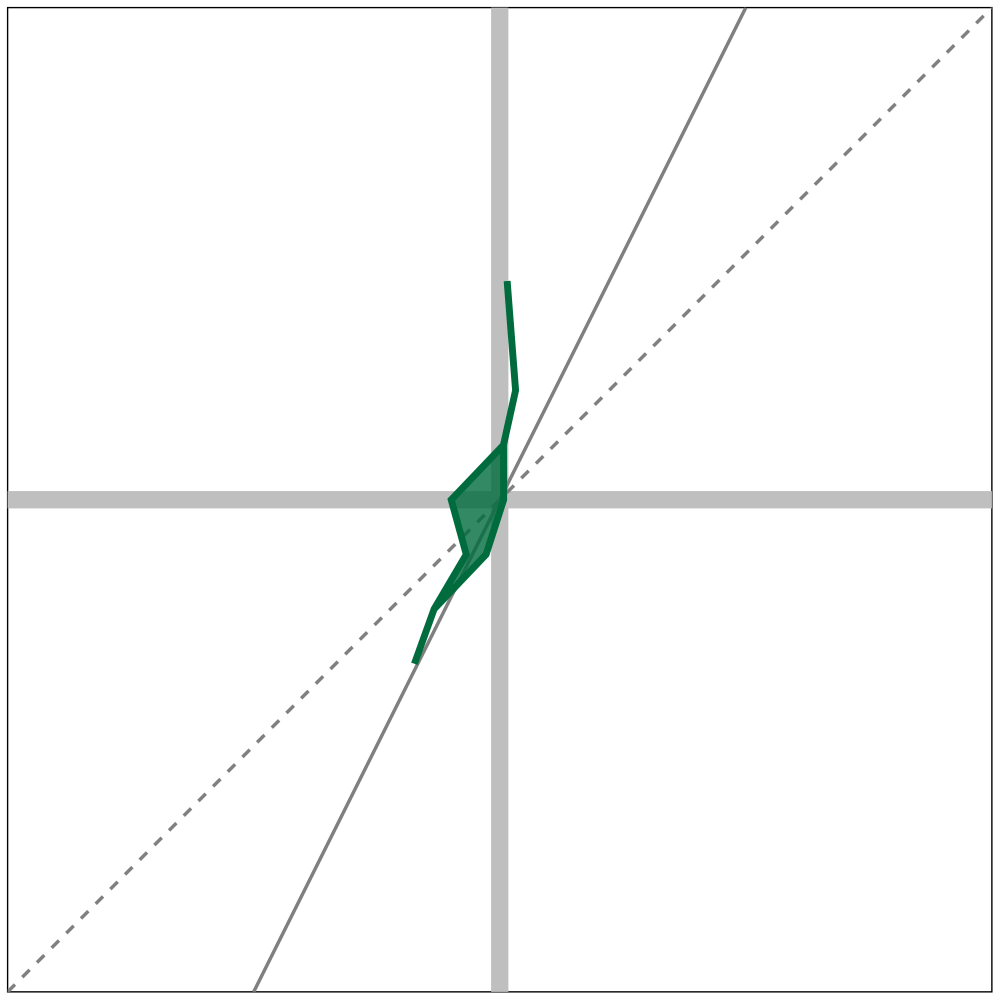

In [5]:
plot = PaintBall(
    voteshare_data=[0.4925, 0.5233, 0.4960, 0.5259, 0.4839, 0.5340, 0.5867, 0.4962, 0.5667, 0.5139, 0.5060, 0.5493],
    seats_data=[5,10,9,9,7,10,12,8,11,10,9,9],
    maximum_seats=18
)
plot.print(hull=True)
plot.preview(hull=True)

## Other Possible modifications

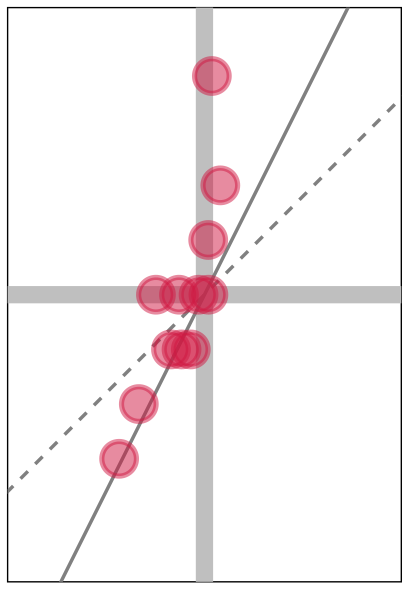

In [6]:
plot = PaintBall(
    voteshare_data=[0.4925, 0.5233, 0.4960, 0.5259, 0.4839, 0.5340, 0.5867, 0.4962, 0.5667, 0.5139, 0.5060, 0.5493],
    seats_data=[5,10,9,9,7,10,12,8,11,10,9,9],
    maximum_seats=18
)

plot.set_xlim(0.3, 0.7)
plot.set_ylim(3.75/18, 14.25/18)
plot.set_marker_options(
    size=10,
    color="alizarin",
    alpha=0.5,
    edgecolor="alizarin",
    edgewidth=1.5,
    edgealpha=0.5
)
plot.preview()

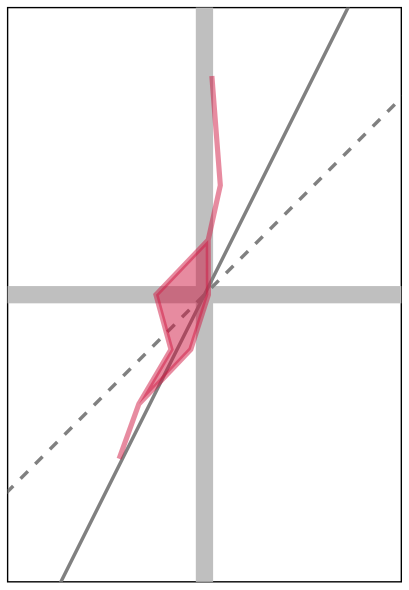

In [7]:
plot = PaintBall(
    voteshare_data=[0.4925, 0.5233, 0.4960, 0.5259, 0.4839, 0.5340, 0.5867, 0.4962, 0.5667, 0.5139, 0.5060, 0.5493],
    seats_data=[5,10,9,9,7,10,12,8,11,10,9,9],
    maximum_seats=18
)

plot.set_xlim(0.3, 0.7)
plot.set_ylim(3.75/18, 14.25/18)
plot.set_hull_options(
    color="alizarin",
    alpha=0.5,
    edgecolor="alizarin",
    edgewidth=1.5,
    edgealpha=0.5
)
plot.preview(hull=True)